In [67]:
from pathlib import Path
import os
import subprocess
import getpass
import shutil

def local_run():
    if os.path.exists("/content"):
        # running in Google Colab
        return False
    else:
        # running locally
        return True

def get_base_dir():
    if local_run():
        # running locally
        return Path(__vsc_ipynb_file__).resolve().parent.parent
    else:
        # running in Google Colab
        return Path("/content/deforestation-unet")

base_dir = get_base_dir()
print(f"Base directory: {base_dir}")

Base directory: C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet


In [68]:
repo_url = f"https://@github.com/barbara-barta/deforestation-unet.git"
if not base_dir.exists():
    print("Repository does not exist, cloning it now.")
    subprocess.run(["git", "clone", repo_url], check=True)
else:
    print("Repository already exists, pulling the latest changes.")
    subprocess.run(["git", "-C", str(base_dir), "pull"], check=True)

Repository already exists, pulling the latest changes.


In [3]:
%pip install -r {base_dir}/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [69]:
import torch
import rasterio as rio
import rasterio.plot as rplt
import geopandas as gpd
import numpy as np
import random
import matplotlib.pyplot as plt
import torchvision
import patoolib
import torch.nn as nn

In [70]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}.")

# Function for setting the seed
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu.


In [71]:
CHECKPOINT_PATH = f"{base_dir}/models"

paths = {
    "RGB": base_dir / "data" / "RGB" /"raw",
    "AM4": base_dir / "data" / "AM4" / "raw",
    "AT4": base_dir / "data" / "AT4" / "raw",
}

downloads = {
    "RGB": ["https://doi.org/10.5281/zenodo.3233081", "Amazon Forest Dataset.rar"],
    "AM4": ["https://doi.org/10.5281/zenodo.4498086","AMAZON.rar"]
    ,"AT4": ["https://doi.org/10.5281/zenodo.4498086","ATLANTIC FOREST.rar"]}

for path in paths.values():
    path.mkdir(parents=True, exist_ok=True)

# Mount Google Drive if running in Colab
drive_dir = None
if not local_run():
    from google.colab import drive

    drive.mount("/content/drive")

    drive_dir = Path("/content/drive/MyDrive")
    drive_dir.mkdir(parents=True, exist_ok=True)



In [72]:
# Download + extract datasets
for dataset, (url, filename) in downloads.items():
    dataset_path = paths[dataset]
    local_zip_path = dataset_path / filename
    drive_zip_path = (
        drive_dir / filename if drive_dir is not None else None
    )
    # Determine where zip file exists
    zip_source_path = None
    if drive_zip_path is not None and drive_zip_path.exists():
        zip_source_path = drive_zip_path
        print(f"{dataset}: found zip in Google Drive in location {zip_source_path}.")
    elif local_zip_path.exists():
        zip_source_path = local_zip_path
        print(f"{dataset}: found zip locally in location {zip_source_path}.")
    else:
        print(f"Downloading {dataset} dataset...")
        cmd = [
            "zenodo_get",
            "-o",
            str(dataset_path),
            "-g",
            filename,
            url,
        ]

        subprocess.run(cmd, check=True)
        zip_source_path = local_zip_path
        print(f"{dataset} downloaded to {dataset_path}")

        # Save a copy to Google Drive in Colab
        if drive_dir is not None:
            drive_copy = drive_dir / filename
            if not drive_copy.exists():
                shutil.copy2(local_zip_path, drive_copy)
                print(f"Copied {dataset} zip to Google Drive.")

    # Extract archive
    extracted_dir_name = filename.rsplit(".", 1)[0]
    normalized_name = (
        extracted_dir_name.lower().replace(" ", "_")
    )
    final_dataset_dir = dataset_path / normalized_name

    if final_dataset_dir.exists():
        print(f"{dataset} already extracted. Skipping extraction.")
        continue

    print(f"Extracting {dataset}...")

    patoolib.extract_archive(
        str(zip_source_path),
        outdir=str(dataset_path),
    )

    # Rename extracted folder if needed
    extracted_path = dataset_path / extracted_dir_name
    if extracted_path.exists() and extracted_path != final_dataset_dir:
        extracted_path.rename(final_dataset_dir)

    print(f"{dataset} extracted to {final_dataset_dir}")

RGB: found zip locally in location C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\RGB\raw\Amazon Forest Dataset.rar.
RGB already extracted. Skipping extraction.
AM4: found zip locally in location C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\AM4\raw\AMAZON.rar.
AM4 already extracted. Skipping extraction.
AT4: found zip locally in location C:\Users\barba\Documents\ProfessionalBetterment\deforestation-unet\data\AT4\raw\ATLANTIC FOREST.rar.
AT4 already extracted. Skipping extraction.


In [73]:
file_path = f"{base_dir}/data/AM4/raw/amazon/Validation/masks/S2B_MSIL2A_20200202T141649_N0213_R010_T20LQN_20200202T164215_12_07.tif.aux.xml"

if os.path.exists(file_path):
    os.remove(file_path)
    print("File deleted.")
else:
    print("File does not exist.")

File does not exist.


# Data exploration

In [ ]:
img = "Amazon_122.tiff_33.tiff"
img_path = base_dir / "data" / "DummyData" / img
src = rio.open(img_path)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 3,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(9.016735026040612e-05, 0.0, -47.414771816388885,
        0.0, -8.990264377170196e-05, -4.399063756666667)}

In [33]:
#expressed in degrees as crs = WGS 84
print(f"Spatial resolution is {src.res} degrees.")
print(f"Bounds of the area are {src.bounds} degrees.")

Spatial resolution is (10.0, 10.0) degrees.
Bounds of the area are BoundingBox(left=405080.0, bottom=8294900.0, right=410200.0, top=8300020.0) degrees.


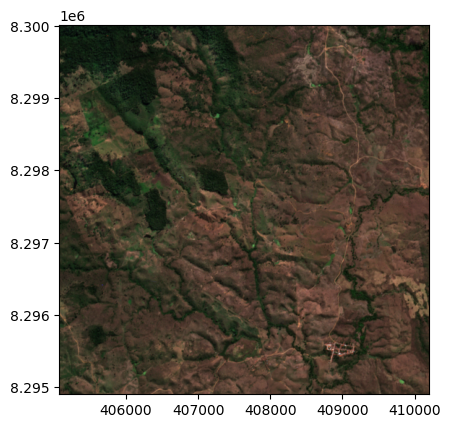

<Axes: >

In [34]:
rplt.show(src)

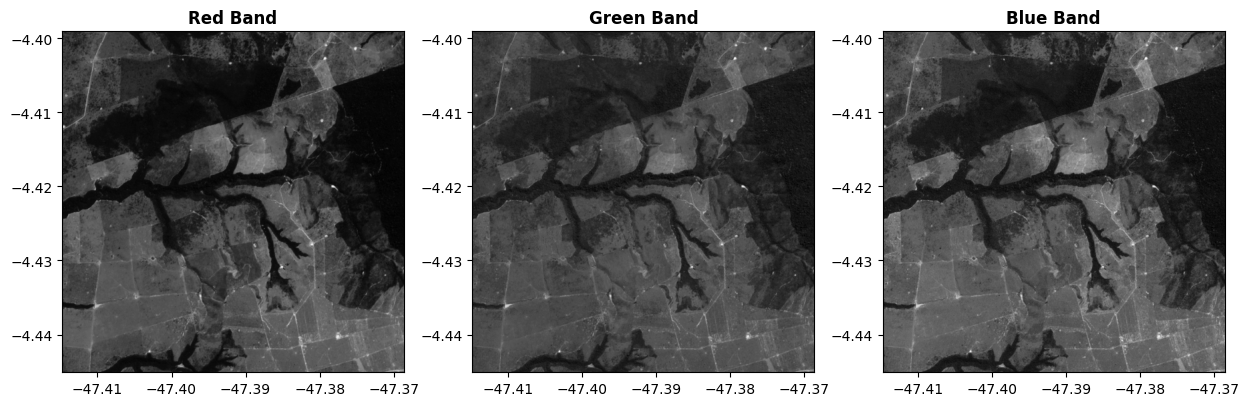

In [ ]:
nr_bands = src.count
fig, axes = plt.subplots(1, nr_bands, figsize=(15, 15))
axes = axes.flatten()
titles = ["Red Band", "Green Band", "Blue Band"]
for i in range(axes.shape[0]):
    rplt.show((src, i+1), ax=axes[i], cmap='Greys_r', title = titles[i])

In [28]:
img = "S2A_MSIL2A_20190715T125311_N0213_R052_T24LVH_20190715T150206_01_02.tif"
img_path = base_dir / "data" / "AT4" / "raw" / "atlantic_forest" / "Training" / "image" / img
src = rio.open(img_path)
src.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 512,
 'height': 512,
 'count': 4,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 24S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32724"]]'),
 'transform': Affine(10.0, 0.0, 405080.0,
        0.0, -10.0, 8300020.0)}

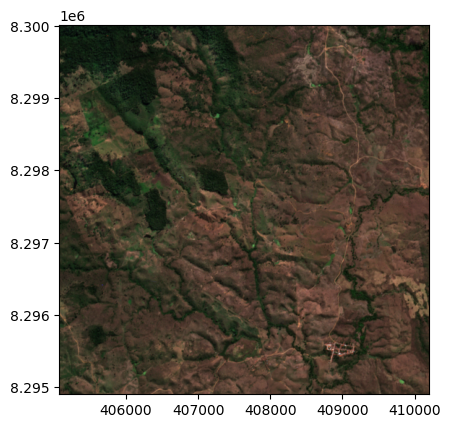

<Axes: >

In [29]:

rplt.show(src)

In [30]:
# NIR band
src.read(4)
src.profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 512, 'height': 512, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 24S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32724"]]'), 'transform': Affine(10.0, 0.0, 405080.0,
       0.0, -10.0, 8300020.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}

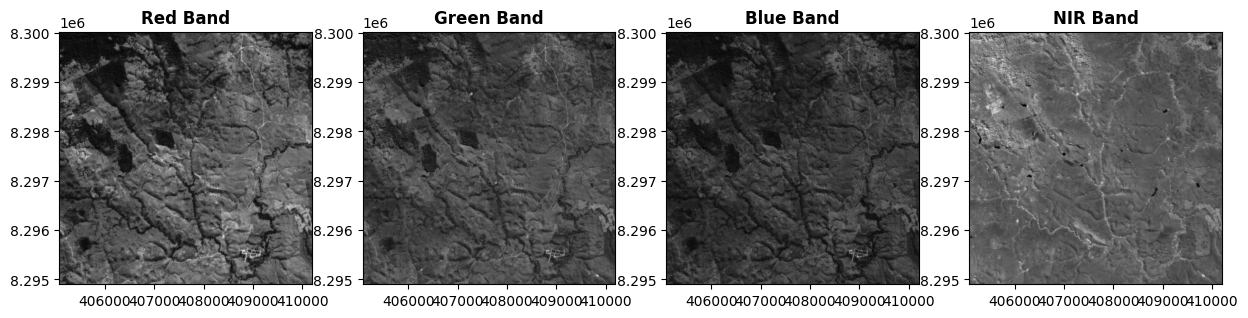

In [31]:
nr_bands = src.count
fig, axes = plt.subplots(1, nr_bands, figsize=(15, 15))
axes = axes.flatten()
titles = ["Red Band", "Green Band", "Blue Band", "NIR Band"]
for i in range(axes.shape[0]):
    rplt.show((src, i+1), ax=axes[i], cmap='Greys_r', title = titles[i])

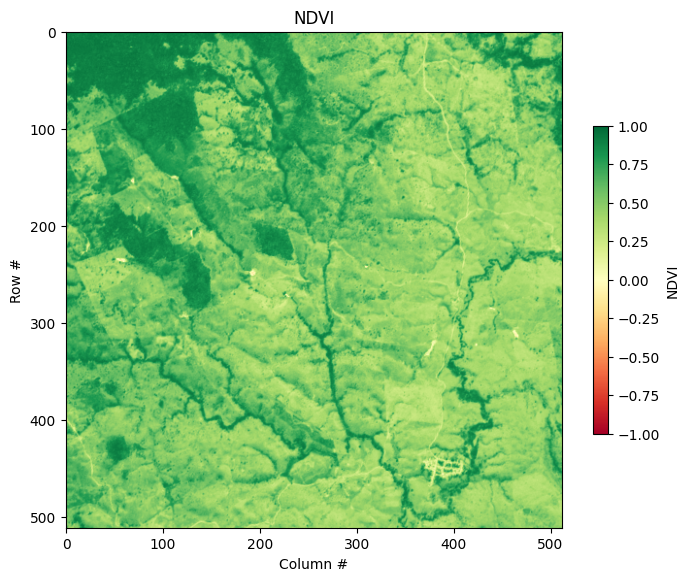

In [32]:
nir_band = src.read(4).astype('float32')
red_band = src.read(1).astype('float32')
ndvi = (nir_band - red_band) / (nir_band + red_band)
ndvi = ndvi.clip(-1, 1)

plt.figure(figsize=(8, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI", shrink=0.5)
plt.title("NDVI")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

## Dataset quality concerns

RGB:
- 60 imgs from sentinel-2 satelite imagery
- max 30% cloud coverage in each picture
- 8-BIT geoTiff format?
- sr: 10m/pixel
- forest masks obtained from a land use classification process using GRASS-GIS 7.6.1 software -> automated
AM4:


# Creating the dataset class and data loader

In [74]:
from torch.utils.data import Dataset, DataLoader
class DeforestationDataset(Dataset):
    def __init__(self, root_directory,image_name,label_name,indices = None, transform=None):
        self.root_directory = root_directory
        self.image_directory = self.root_directory / str(image_name)
        self.label_directory = self.root_directory / str(label_name)
        self.transform = transform
        self.indices = indices

    def __len__(self):
        if self.indices:
            dataset_size = len(self.indices)
        else:
            dataset_size = len(list(Path(self.image_directory).glob("*")))
        return dataset_size

    def __getitem__(self, index):
        if self.indices:
            img_path = list(Path(self.image_directory).glob("*"))[self.indices[index]]
            lbl_path = list(Path(self.label_directory).glob("*"))[self.indices[index]]
        else:
            img_path = list(Path(self.image_directory).glob("*"))[index]
            lbl_path = list(Path(self.label_directory).glob("*"))[index]
        img = rio.open(img_path)
        img = img.read().astype('float32')
        if self.transform:
            img = self.transform(img)

        lbl = rio.open(lbl_path)
        lbl = lbl.read().astype('float32')

        sample = [img,torch.from_numpy(lbl)]
        return sample

if local_run():
    batch_size = 4
    num_workers = 0
else:
    batch_size = 32
    num_workers = 4


In [75]:
from torchvision import transforms

class min_max_scale():
    def __init__(self):
        pass

    def __call__(self,img):
        img_min,img_max = np.min(img),np.max(img)
        img_scaled =  (img - img_min)/(img_max-img_min)
        return img_scaled

class to_tensor():
    def __init__(self):
        pass
    def __call__(self,img):
        return torch.from_numpy(img)

train_transform = transforms.Compose([
    min_max_scale(),

    to_tensor()
])

train_dataset_am4 = DeforestationDataset(base_dir / "data" / "AM4" / "raw" / "amazon" / "Training","image","label",transform = train_transform)
test_dataset_am4 = DeforestationDataset(base_dir / "data" / "AM4" / "raw" / "amazon" / "Test","image","mask",transform = train_transform)
val_dataset_am4 = DeforestationDataset(base_dir / "data" / "AM4" / "raw" / "amazon" / "Validation","images","masks",transform = train_transform)

sample = train_dataset_am4[0][0] #first sample, image only
print(f"After transform, min of sample is {torch.min(sample)}, max is {torch.max(sample)}.") # check
print(f"After transform, shape of sample is {sample.shape}") # check
print(f"Size of train dataset is {len(train_dataset_am4)}, size of val dataset is {len(val_dataset_am4)}, size of test dataset is {len(test_dataset_am4)}.")

train_dataloader_am4 = DataLoader(train_dataset_am4,batch_size=batch_size, shuffle=True,num_workers=num_workers, pin_memory=True)
test_dataloader_am4 = DataLoader(test_dataset_am4,batch_size=batch_size, shuffle=False,num_workers=num_workers, pin_memory=True)
val_dataloader_am4 = DataLoader(val_dataset_am4,batch_size=batch_size, shuffle=False,num_workers=num_workers, pin_memory=True)


After transform, min of sample is 0.0, max is 1.0.
After transform, shape of sample is torch.Size([4, 512, 512])
Size of train dataset is 499, size of val dataset is 100, size of test dataset is 20.


# U-net and Attention U-net architectures

In [76]:
class DoubleConv(nn.Module):
    def __init__(self,n_input,n_output):
        super().__init__()
        self.linear1 = nn.Conv2d(n_input,n_output,kernel_size=3, stride =1, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.linear2 = nn.Conv2d(n_output,n_output,kernel_size=3, stride =1, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.functions = nn.Sequential(self.linear1,self.relu1,self.linear2,self.relu2)

    def forward(self,x):
         return self.functions(x)

class Downsample(nn.Module):
    def __init__(self,n_input,n_output):
        super().__init__()
        self.double_conv = DoubleConv(n_input,n_output)
        self.pool = nn.MaxPool2d(kernel_size=2)

    def forward(self,x):
        h = self.double_conv(x)
        x = self.pool(h)
        return h, x

class Upsample(nn.Module):
    def __init__(self,n_input,n_output):
        super().__init__()
        self.conv_transpose = nn.ConvTranspose2d(n_input,n_output,kernel_size=2, stride=2)
        self.double_conv = DoubleConv(n_input,n_output)

    def forward(self,h,x):
        x = self.conv_transpose(x)
        x = torch.cat([x,h],dim=1)
        x = self.double_conv(x)
        return x

class UNet(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.downsample1 = Downsample(num_inputs,64)
        self.downsample2 = Downsample(64,128)
        self.downsample3 = Downsample(128,256)
        self.downsample4 = Downsample(256,512)
        self.bottleneck = DoubleConv(512,1024)
        self.upsample1 = Upsample(1024,512)
        self.upsample2 = Upsample(512,256)
        self.upsample3 = Upsample(256,128)
        self.upsample4 = Upsample(128,64)
        self.conv2nd = nn.Conv2d(64,num_outputs,kernel_size=1)

    def forward(self,x):
        h1,x = self.downsample1(x)
        h2,x = self.downsample2(x)
        h3,x = self.downsample3(x)
        h4,x = self.downsample4(x)
        x = self.bottleneck(x)
        x = self.upsample1(h4,x)
        x = self.upsample2(h3,x)
        x = self.upsample3(h2,x)
        x = self.upsample4(h1,x)
        x = self.conv2nd(x)
        return x

# unet = UNet(num_inputs=4,num_outputs=1)
# sample = next(iter(train_dataloader_am4))[0]
# unet(sample).shape


In [77]:
class AttentionGate(nn.Module):
    def __init__(self,n_input_x,n_input_g):
        super().__init__()
        self.conv_x = nn.Conv2d(n_input_x, n_input_x, kernel_size=1, stride = 2, padding = 0) #figure out stride and padding so that its resolutions changes to that of g
        self.conv_g = nn.Conv2d(n_input_g, n_input_x, kernel_size=1, stride = 1, padding = 0)
        self.relu = nn.ReLU(inplace=True)
        self.conv_attn = nn.Conv2d(n_input_x, 1, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)


    def forward(self,x,g):
        y = self.conv_x(x)
        g = self.conv_g(g)
        y = self.relu(y+g)
        attn = self.conv_attn(y)
        attn = self.sigmoid(attn)
        attn = self.upsample(attn)
        y = attn * x
        return y

class AttentionUNet(nn.Module):
    def __init__(self,num_inputs, num_outputs):
        super().__init__()
        self.downsample1 = Downsample(num_inputs,16)
        self.downsample2 = Downsample(16,32)
        self.downsample3 = Downsample(32,64)
        self.downsample4 = Downsample(64,128)
        self.bottleneck = DoubleConv(128,256)
        self.upsample1 = Upsample(256,128)
        self.upsample2 = Upsample(128,64)
        self.upsample3 = Upsample(64,32)
        self.upsample4 = Upsample(32,16)
        self.conv2nd = nn.Conv2d(16,num_outputs,kernel_size=1)
        self.ag1 = AttentionGate(128,256)
        self.ag2 = AttentionGate(64,128)
        self.ag3 = AttentionGate(32,64)
        self.ag4 = AttentionGate(16,32)

    def forward(self,x):
        g1,x = self.downsample1(x)
        g2,x = self.downsample2(x)
        g3,x = self.downsample3(x)
        g4,x = self.downsample4(x)
        x = self.bottleneck(x)
        g4 = self.ag1(g4,x)
        x = self.upsample1(g4,x)
        g3 = self.ag2(g3,x)
        x = self.upsample2(g3,x)
        g2 = self.ag3(g2,x)
        x = self.upsample3(g2,x)
        g1 = self.ag4(g1,x)
        x = self.upsample4(g1,x)
        x = self.conv2nd(x)
        return x


# attUnet = AttentionUNet(num_inputs = 4,num_outputs = 1)
# sample = next(iter(train_dataloader_am4))[0]
# output = attUnet(sample)

In [78]:
def train_and_eval(model_name, model_hparams, optimizer_name, optimizer_hparams, num_epochs, train_dataloader, val_dataloader, attention, seed = 0):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    saved_model = Path(CHECKPOINT_PATH) / f"{model_name}_{seed}.pt"
    if seed is not None:
        print(f"Setting seed equal to {seed}.")
        set_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    if attention:
        model = AttentionUNet(**model_hparams).to(device)
    else:
        model = UNet(**model_hparams).to(device)

    optimizer = getattr(torch.optim, optimizer_name)(
        model.parameters(),
        **optimizer_hparams
    )

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    train_losses, train_precisions, train_recalls, train_f1s, train_ious, val_losses, val_precisions, val_recalls, val_f1s, val_ious = [], [], [], [], [], [], [], [], [], []

    for epoch in range(num_epochs):

        # training
        model.train()
        train_loss = 0.0
        train_precision = 0.0
        total_tp = 0
        total_fp = 0
        total_fn = 0
        for images, masks in train_dataloader:

            images = images.to(device)
            masks = masks.to(device).float()
            masks = masks.unsqueeze(1) if masks.ndim == 3 else masks

            optimizer.zero_grad()
            outputs = model(images)

            assert outputs.shape == masks.shape, (outputs.shape, masks.shape)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = (outputs > 0.).float()

            tp = (preds * masks).sum().item()
            fp = (preds * (1 - masks)).sum().item()
            fn = ((1 - preds) * masks).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

        train_loss /= len(train_dataloader.dataset)
        train_precision = total_tp / (total_tp + total_fp + 1e-8)
        train_recall = total_tp / (total_tp + total_fn + 1e-8)
        train_f1 = 2 * train_precision * train_recall / (train_precision + train_recall + 1e-8)
        train_iou = total_tp / (total_tp + total_fp + total_fn + 1e-8)

        train_losses.append(train_loss)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)
        train_ious.append(train_iou)

        # validation
        model.eval()
        val_loss = 0.0
        val_precision = 0.0
        total_tp = 0
        total_fp = 0
        total_fn = 0
        with torch.no_grad():
            for images, masks in val_dataloader:
                images = images.to(device)
                masks = masks.to(device).float()

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item() * images.size(0)
                preds = (outputs > 0.).float()

                tp = (preds * masks).sum().item()
                fp = (preds * (1 - masks)).sum().item()
                fn = ((1 - preds) * masks).sum().item()

                total_tp += tp
                total_fp += fp
                total_fn += fn

        val_loss /= len(val_dataloader.dataset)
        val_precision = total_tp / (total_tp + total_fp + 1e-8)
        val_recall = total_tp / (total_tp + total_fn + 1e-8)
        val_f1 = 2 * val_precision * val_recall / (val_precision + val_recall + 1e-8)
        val_iou = total_tp / (total_tp + total_fp + total_fn + 1e-8)

        val_losses.append(val_loss)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)
        val_ious.append(val_iou)

        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Train Precision: {train_precision:.4f}, "
            f"Val Precision: {val_precision:.4f}, "
            f"Train Recall: {train_recall:.4f}, "
            f"Val Recall: {val_recall:.4f}, "
            f"Train F1: {train_f1:.4f}, "
            f"Val F1: {val_f1:.4f}, "
            f"Train IoU: {train_iou:.4f}, "
            f"Val IoU: {val_iou:.4f}"
        )

        # checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), saved_model)
            print(f"Saved best model: {best_val_loss:.4f}")

    return model, [train_losses, train_precisions, train_recalls, train_f1s, train_ious], [val_losses, val_precisions, val_recalls, val_f1s, val_ious]

In [79]:
def eval(model, dataloader):

  model.eval()
  criterion = nn.BCEWithLogitsLoss()
  total_tp = 0
  total_fp = 0
  total_fn = 0
  loss = 0.0

  with torch.no_grad():
      for images, masks in dataloader:

          images = images.to(device)
          masks = masks.to(device).float()
          outputs = model(images)
          batch_loss = criterion(outputs, masks)
          loss += batch_loss.item() * images.size(0)
          preds = (outputs > 0.).float()

          tp = (preds * masks).sum().item()
          fp = (preds * (1 - masks)).sum().item()
          fn = ((1 - preds) * masks).sum().item()

          total_tp += tp
          total_fp += fp
          total_fn += fn


  loss = loss / len(dataloader.dataset)
  precision = total_tp / (total_tp + total_fp + 1e-8)
  recall = total_tp / (total_tp + total_fn + 1e-8)
  f1 = 2 * precision * recall / (precision + recall + 1e-8)
  iou = total_tp / (total_tp + total_fp + total_fn + 1e-8)

  print(
      f"Loss: {loss:.4f}, "
      f"Precision: {precision:.4f}, "
      f"Recall: {recall:.4f}, "
      f"F1: {f1:.4f}, "
      f"IoU: {iou:.4f}"
  )
  
  return loss, precision, recall, f1, iou



In [99]:
import seaborn as sns

# def plot_precision(train_precisions, val_precisions):
#     plt.figure(figsize=(8, 6))
#     plt.plot(train_precisions, label="Train Precision")
#     plt.plot(val_precisions, label="Validation Precision")
#     plt.xlabel("Epoch")
#     plt.ylabel("Precision")
#     plt.title("Training and Validation Precision")
#     plt.legend()
#     plt.grid()
#     sns.set(style="whitegrid", palette="muted")

def plot_precision(train_precisions, val_precisions):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=train_precisions, label="Train Precision", marker="o")
    sns.lineplot(data=val_precisions, label="Validation Precision", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Training and Validation Precision")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=train_losses, label="Train Loss", marker="o")
    sns.lineplot(data=val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# def plot_loss(train_losses, val_losses):
#     plt.figure(figsize=(8, 6))
#     plt.plot(train_losses, label="Train Loss")
#     plt.plot(val_losses, label="Validation Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title("Training and Validation Loss")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [16]:
from google.colab import files, runtime

for i in range(3):
    model_name = "unet_am4"
    model_am4, metrics_am4_train, metrics_am4_val = train_and_eval(
    model_name=model_name,
    model_hparams={"num_inputs": 4, "num_outputs": 1},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-4},
    num_epochs=20,
    train_dataloader = train_dataloader_am4,
    val_dataloader = val_dataloader_am4,
    attention = False,
    seed = i)
    [loss_am4_train,precisions_am4_train, recalls_am4_train, f1s_am4_train, ious_am4_train] = metrics_am4_train
    [loss_am4_val, precisions_am4_val, recalls_am4_val, f1s_am4_val, ious_am4_val] = metrics_am4_val

    torch.save(metrics_am4_train, Path(CHECKPOINT_PATH) / f"{model_name}_metrics_train_{i}.pt")
    torch.save(metrics_am4_val, Path(CHECKPOINT_PATH) / f"{model_name}_metrics_val_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) /f"{model_name}_metrics_train_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) /f"{model_name}_metrics_val_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) / f"{model_name}_{i}.pt")


Setting seed equal to 0.
Epoch 1/20, Train Loss: 0.6887, Val Loss: 0.6840, Train Precision: 0.5287, Val Precision: 0.5267, Train Recall: 1.0000, Val Recall: 1.0000, Train F1: 0.6917, Val F1: 0.6899, Train IoU: 0.5287, Val IoU: 0.5267
Saved best model: 0.6840
Epoch 2/20, Train Loss: 0.6683, Val Loss: 0.6381, Train Precision: 0.6136, Val Precision: 0.7625, Train Recall: 0.9992, Val Recall: 0.9922, Train F1: 0.7603, Val F1: 0.8623, Train IoU: 0.6133, Val IoU: 0.7580
Saved best model: 0.6381
Epoch 3/20, Train Loss: 0.5246, Val Loss: 0.4259, Train Precision: 0.8526, Val Precision: 0.8525, Train Recall: 0.8704, Val Recall: 0.8759, Train F1: 0.8614, Val F1: 0.8640, Train IoU: 0.7565, Val IoU: 0.7606
Saved best model: 0.4259
Epoch 4/20, Train Loss: 0.3323, Val Loss: 0.2861, Train Precision: 0.8558, Val Precision: 0.8452, Train Recall: 0.9242, Val Recall: 0.9495, Train F1: 0.8887, Val F1: 0.8943, Train IoU: 0.7997, Val IoU: 0.8088
Saved best model: 0.2861
Epoch 5/20, Train Loss: 0.2429, Val Los

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for i in range(3):
    model_name = "unet_attn_am4"
    model_am4, metrics_am4_train, metrics_am4_val = train_and_eval(
    model_name=model_name,
    model_hparams={"num_inputs": 4, "num_outputs": 1},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 5e-4},
    num_epochs=60,
    train_dataloader = train_dataloader_am4,
    val_dataloader = val_dataloader_am4,
    attention = True,
    seed = i)

    [loss_am4_train,precisions_am4_train, recalls_am4_train, f1s_am4_train, ious_am4_train] = metrics_am4_train
    [loss_am4_val, precisions_am4_val, recalls_am4_val, f1s_am4_val, ious_am4_val] = metrics_am4_val

    torch.save(metrics_am4_train, Path(CHECKPOINT_PATH) / f"{model_name}_metrics_train_{i}.pt")
    torch.save(metrics_am4_val, Path(CHECKPOINT_PATH) / f"{model_name}_metrics_val_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) /f"{model_name}_metrics_train_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) /f"{model_name}_metrics_val_{i}.pt")
    files.download(Path(CHECKPOINT_PATH) / f"{model_name}_{i}.pt")



Setting seed equal to 0.
Epoch 1/60, Train Loss: 0.6914, Val Loss: 0.6889, Train Precision: 0.5286, Val Precision: 0.5219, Train Recall: 1.0000, Val Recall: 1.0000, Train F1: 0.6916, Val F1: 0.6858, Train IoU: 0.5286, Val IoU: 0.5219
Saved best model: 0.6889
Epoch 2/60, Train Loss: 0.6746, Val Loss: 0.6334, Train Precision: 0.5332, Val Precision: 0.6913, Train Recall: 1.0000, Val Recall: 0.9997, Train F1: 0.6955, Val F1: 0.8174, Train IoU: 0.5332, Val IoU: 0.6912
Saved best model: 0.6334
Epoch 3/60, Train Loss: 0.4769, Val Loss: 0.4138, Train Precision: 0.8268, Val Precision: 0.7983, Train Recall: 0.9245, Val Recall: 0.9652, Train F1: 0.8730, Val F1: 0.8738, Train IoU: 0.7745, Val IoU: 0.7759
Saved best model: 0.4138
Epoch 4/60, Train Loss: 0.3525, Val Loss: 0.3143, Train Precision: 0.8931, Val Precision: 0.8298, Train Recall: 0.9241, Val Recall: 0.9685, Train F1: 0.9084, Val F1: 0.8938, Train IoU: 0.8321, Val IoU: 0.8080
Saved best model: 0.3143
Epoch 5/60, Train Loss: 0.2445, Val Los

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Setting seed equal to 1.
Epoch 1/60, Train Loss: 0.6913, Val Loss: 0.6910, Train Precision: 0.5286, Val Precision: 0.5219, Train Recall: 1.0000, Val Recall: 1.0000, Train F1: 0.6916, Val F1: 0.6858, Train IoU: 0.5286, Val IoU: 0.5219
Saved best model: 0.6910
Epoch 2/60, Train Loss: 0.6860, Val Loss: 0.6754, Train Precision: 0.5289, Val Precision: 0.5301, Train Recall: 1.0000, Val Recall: 1.0000, Train F1: 0.6919, Val F1: 0.6929, Train IoU: 0.5289, Val IoU: 0.5301
Saved best model: 0.6754
Epoch 3/60, Train Loss: 0.6317, Val Loss: 0.4988, Train Precision: 0.7261, Val Precision: 0.9509, Train Recall: 0.9148, Val Recall: 0.6915, Train F1: 0.8096, Val F1: 0.8007, Train IoU: 0.6801, Val IoU: 0.6676
Saved best model: 0.4988
Epoch 4/60, Train Loss: 0.4700, Val Loss: 0.4053, Train Precision: 0.8897, Val Precision: 0.8963, Train Recall: 0.8844, Val Recall: 0.9004, Train F1: 0.8870, Val F1: 0.8983, Train IoU: 0.7970, Val IoU: 0.8154
Saved best model: 0.4053
Epoch 5/60, Train Loss: 0.3370, Val Los

## Results

In [84]:
precisions_am4_val, recalls_am4_val, f1s_am4_val, ious_am4_val = [], [], [], []
precisions_am4_test, recalls_am4_test, f1s_am4_test, ious_am4_test = [], [], [], []

for i in range(3):
    model_name = f"unet_attn_am4_{i}"
    model = AttentionUNet(num_inputs=4,num_outputs=1).to(device)
    model.load_state_dict(torch.load(Path(CHECKPOINT_PATH) / f"{model_name}.pt", map_location=torch.device('cpu')))
    
    loss, precision, recall, f1, iou = eval(model,val_dataloader_am4)
    precisions_am4_val.append(precision)
    recalls_am4_val.append(recall)
    f1s_am4_val.append(f1)
    ious_am4_val.append(iou)
    
    loss, precision, recall, f1, iou = eval(model,test_dataloader_am4)
    precisions_am4_test.append(precision)
    recalls_am4_test.append(recall)
    f1s_am4_test.append(f1)
    ious_am4_test.append(iou)

print("Validation Metrics for Attention UNet on AM4:")
print(f"precision mean: {np.mean(precisions_am4_val):.4f}, precision std: {np.std(precisions_am4_val):.4f}")
print(f"recall mean: {np.mean(recalls_am4_val):.4f}, recall std: {np.std(recalls_am4_val):.4f}")
print(f"f1 mean: {np.mean(f1s_am4_val):.4f}, f1 std: {np.std(f1s_am4_val):.4f}")
print(f"iou mean: {np.mean(ious_am4_val):.4f}, iou std: {np.std(ious_am4_val):.4f}")

print("Test Metrics for Attention UNet on AM4:")
print(f"precision mean: {np.mean(precisions_am4_test):.4f}, precision std: {np.std(precisions_am4_test):.4f}")
print(f"recall mean: {np.mean(recalls_am4_test):.4f}, recall std: {np.std(recalls_am4_test):.4f}")
print(f"f1 mean: {np.mean(f1s_am4_test):.4f}, f1 std: {np.std(f1s_am4_test):.4f}")
print(f"iou mean: {np.mean(ious_am4_test):.4f}, iou std: {np.std(ious_am4_test):.4f}")


Loss: 0.0662, Precision: 0.9752, Recall: 0.9752, F1: 0.9752, IoU: 0.9516
Loss: 0.0702, Precision: 0.9772, Recall: 0.9665, F1: 0.9718, IoU: 0.9452
Loss: 0.0671, Precision: 0.9735, Recall: 0.9767, F1: 0.9751, IoU: 0.9514
Loss: 0.0725, Precision: 0.9760, Recall: 0.9653, F1: 0.9706, IoU: 0.9429
Loss: 0.0679, Precision: 0.9701, Recall: 0.9788, F1: 0.9744, IoU: 0.9501
Loss: 0.0698, Precision: 0.9724, Recall: 0.9722, F1: 0.9723, IoU: 0.9461
Validation Metrics for Attention UNet on AM4:
precision mean: 0.9729, precision std: 0.0021
recall mean: 0.9769, recall std: 0.0015
f1 mean: 0.9749, f1 std: 0.0004
iou mean: 0.9511, iou std: 0.0007
Test Metrics for Attention UNet on AM4:
precision mean: 0.9752, precision std: 0.0020
recall mean: 0.9680, recall std: 0.0030
f1 mean: 0.9716, f1 std: 0.0007
iou mean: 0.9447, iou std: 0.0014


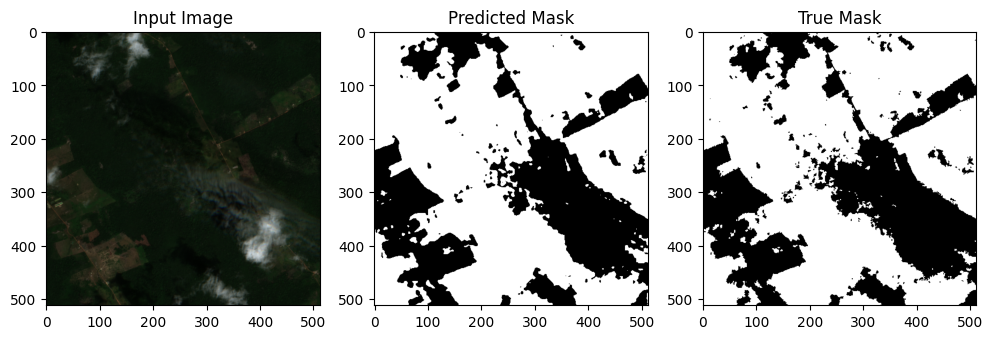

In [93]:
model_name = "unet_attn_am4_0"
model_attn = AttentionUNet(num_inputs=4,num_outputs=1).to(device)
model_attn.load_state_dict(torch.load(Path(CHECKPOINT_PATH) / f"{model_name}.pt", map_location=torch.device('cpu')))
image = train_dataset_am4[1][0].unsqueeze(0).to(device)  # Add batch dimension and move to device
pred = model_attn(image)
pred_mask = (pred > 0.).float().squeeze().cpu().numpy()
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
img_np = image.squeeze().cpu().numpy()
if img_np.ndim == 3 and img_np.shape[0] == 4:
    rgb = np.transpose(img_np[:3], (1, 2, 0))
    plt.imshow(rgb)
else:
    plt.imshow(img_np.squeeze(), cmap='Greys_r')
plt.title("Input Image")
plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.subplot(1, 3, 3)
true_mask = train_dataset_am4[1][1].squeeze().cpu().numpy()
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.show()

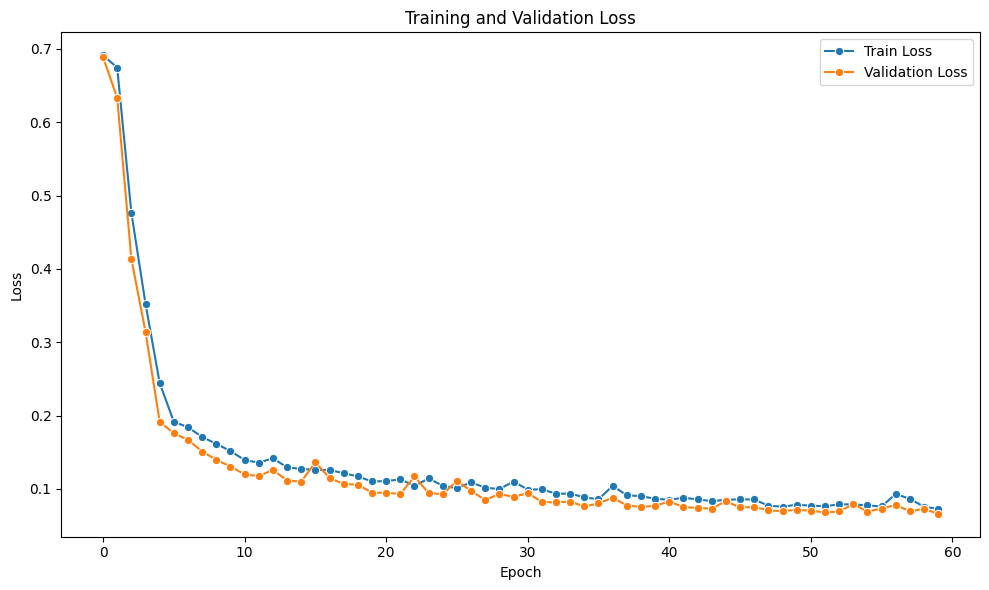

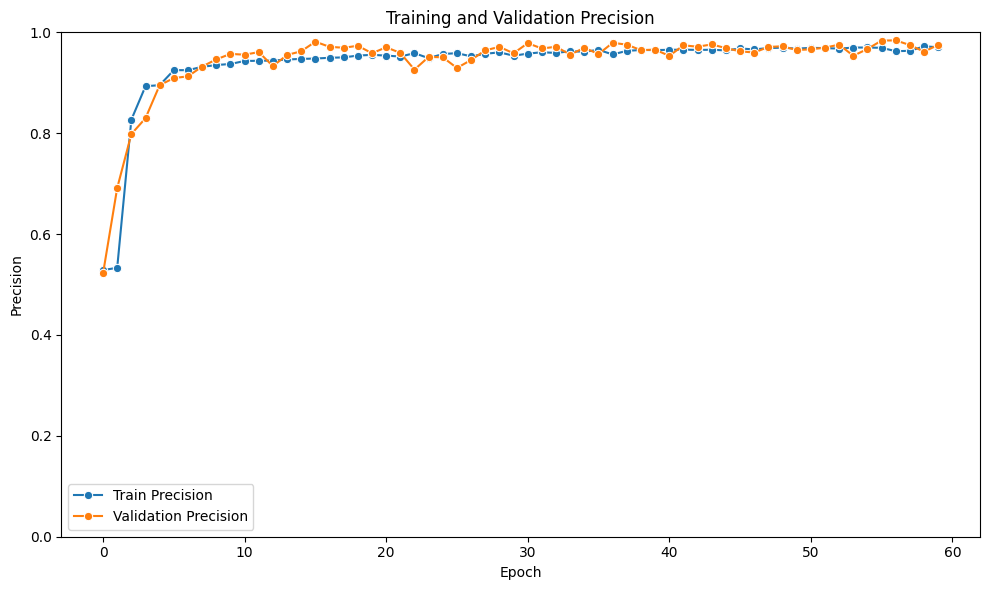

In [101]:
model_name = "unet_attn_am4"
metrics_am4_train = torch.load( Path(CHECKPOINT_PATH) / f"{model_name}_metrics_train_0.pt")
[loss_am4_train,precisions_am4_train, recalls_am4_train, f1s_am4_train, ious_am4_train] = metrics_am4_train
metrics_am4_val = torch.load( Path(CHECKPOINT_PATH) / f"{model_name}_metrics_val_0.pt")
[loss_am4_val, precisions_am4_val, recalls_am4_val, f1s_am4_val, ious_am4_val] = metrics_am4_val
plot_loss(loss_am4_train, loss_am4_val)

plot_precision(precisions_am4_train, precisions_am4_val)

In [85]:
precisions_am4_val, recalls_am4_val, f1s_am4_val, ious_am4_val = [], [], [], []
precisions_am4_test, recalls_am4_test, f1s_am4_test, ious_am4_test = [], [], [], []

for i in range(3):
    model_name = f"unet_am4_{i}"
    model = UNet(num_inputs=4,num_outputs=1).to(device)
    model.load_state_dict(torch.load(Path(CHECKPOINT_PATH) / f"{model_name}.pt", map_location=torch.device('cpu')))
    
    loss, precision, recall, f1, iou = eval(model,val_dataloader_am4)
    precisions_am4_val.append(precision)
    recalls_am4_val.append(recall)
    f1s_am4_val.append(f1)
    ious_am4_val.append(iou)
    
    loss, precision, recall, f1, iou = eval(model,test_dataloader_am4)
    precisions_am4_test.append(precision)
    recalls_am4_test.append(recall)
    f1s_am4_test.append(f1)
    ious_am4_test.append(iou)


print("Validation Metrics for UNet on AM4:")
print(f"precision mean: {np.mean(precisions_am4_val):.4f}, precision std: {np.std(precisions_am4_val):.4f}")
print(f"recall mean: {np.mean(recalls_am4_val):.4f}, recall std: {np.std(recalls_am4_val):.4f}")
print(f"f1 mean: {np.mean(f1s_am4_val):.4f}, f1 std: {np.std(f1s_am4_val):.4f}")
print(f"iou mean: {np.mean(ious_am4_val):.4f}, iou std: {np.std(ious_am4_val):.4f}")

print("Test Metrics for UNet on AM4:")
print(f"precision mean: {np.mean(precisions_am4_test):.4f}, precision std: {np.std(precisions_am4_test):.4f}")
print(f"recall mean: {np.mean(recalls_am4_test):.4f}, recall std: {np.std(recalls_am4_test):.4f}")
print(f"f1 mean: {np.mean(f1s_am4_test):.4f}, f1 std: {np.std(f1s_am4_test):.4f}")
print(f"iou mean: {np.mean(ious_am4_test):.4f}, iou std: {np.std(ious_am4_test):.4f}")


Loss: 0.1119, Precision: 0.9447, Recall: 0.9735, F1: 0.9589, IoU: 0.9210
Loss: 0.1021, Precision: 0.9551, Recall: 0.9686, F1: 0.9618, IoU: 0.9263
Loss: 0.1179, Precision: 0.9578, Recall: 0.9516, F1: 0.9547, IoU: 0.9133
Loss: 0.1198, Precision: 0.9659, Recall: 0.9385, F1: 0.9520, IoU: 0.9084
Loss: 0.1153, Precision: 0.9608, Recall: 0.9507, F1: 0.9557, IoU: 0.9152
Loss: 0.1019, Precision: 0.9707, Recall: 0.9471, F1: 0.9587, IoU: 0.9207
Validation Metrics for UNet on AM4:
precision mean: 0.9545, precision std: 0.0070
recall mean: 0.9586, recall std: 0.0105
f1 mean: 0.9564, f1 std: 0.0018
iou mean: 0.9165, iou std: 0.0033
Test Metrics for UNet on AM4:
precision mean: 0.9639, precision std: 0.0065
recall mean: 0.9514, recall std: 0.0126
f1 mean: 0.9575, f1 std: 0.0041
iou mean: 0.9185, iou std: 0.0075


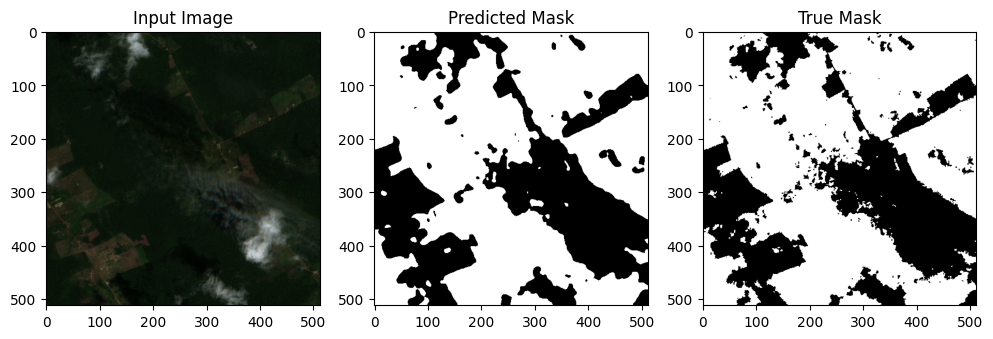

In [92]:
image = train_dataset_am4[1][0].unsqueeze(0).to(device)  # Add batch dimension and move to device
pred = model(image)
pred_mask = (pred > 0.).float().squeeze().cpu().numpy()
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
img_np = image.squeeze().cpu().numpy()
if img_np.ndim == 3 and img_np.shape[0] == 4:
    rgb = np.transpose(img_np[:3], (1, 2, 0))
    plt.imshow(rgb)
else:
    plt.imshow(img_np.squeeze(), cmap='Greys_r')
plt.title("Input Image")
plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.subplot(1, 3, 3)
true_mask = train_dataset_am4[1][1].squeeze().cpu().numpy()
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.show()

## TO DO:

- cretae datasets and dataloaders for atlantic forest
- try to match the numbers in paper as much as possible: check that they use the same parameters for convolution (stride,padding)
## Done this session
-
## Next time
